# Notebook Instructions
English follows Japanese.

## 日本語

このノートブックでは、`mindemo_v4` を用いて、観測データから隠れた従属構造を推定する方法をデモします。  
主に次の2つの例を扱います。

1. **Case 1: Hidden ideal gas law**  
   人工的に生成したデータから、理想気体に対応する不変量 $P 	\times V 	\times 1/T = nR$ を復元できるかを確認します。
2. **Case 2: Penguins**  
   `palmerpenguins` データを用いて、Adelie ペンギンの形態測定値と性別変数の間にある高次の従属関係を調べます。

### 実行前の確認事項

- Google Colab で実行する場合は、Google Drive をマウントし、`mindemo_v4.py` が作業ディレクトリに置かれていることを確認してください。
- ローカル環境で実行する場合は、`google.colab` 関連セルをスキップし、`mindemo_v4.py` が Python の import パス上にあることを確認してください。
- 必要な主要パッケージは `numpy`, `pandas`, `matplotlib`, `scikit-learn`, `scipy`, `networkx`, `palmerpenguins` です。
- Bootstrap を使うセルは計算時間が長くなることがあります。まずは `B=10` などの小さい値で動作確認し、最終結果を確認するときに `B=100` 以上へ戻すことを推奨します。

### 基本的な実行順序

1. ライブラリの import とパッケージのインストールを実行します。
2. 作業ディレクトリを設定し、`mindemo_v4` を import します。
3. Case 1 では、データ生成、可視化、canonical statistics `h` の定義、PLE 推定、Bootstrap 推論を順番に実行します。
4. Case 2 では、データ整形、canonical statistics `h` の定義、PLE 推定、Bootstrap 推論、hypergraph の可視化を順番に実行します。

### 結果の読み方

- 係数プロットでは、0 から大きく離れた項ほど、強い従属関係を示唆します。
- Bootstrap の信頼区間が 0 をまたがない項は、安定した候補として解釈できます。
- `q_value_BH` は Benjamini-Hochberg 法による多重検定補正後の q 値です。値が小さいほど、有意な従属候補である可能性が高いことを示します。
- Case 1 では、`P*V*IT` の項が強く検出されることが期待されます。

### 注意点

- このノートブックの推定結果は、定義した canonical statistics `h` に従属します。`h` に含まれていない相互作用は検出できません。
- Case 2 の Penguin データでは、変数のスケーリングと欠損値の除去を行っています。前処理を変えると結果も変わります。
- グラフや係数の符号は、従属関係の存在を示す補助情報です。推定結果だけから、物理法則や生物学的メカニズムを断定しないでください。
- 再現性を高めたい場合は、乱数シード、サンプルサイズ、Bootstrap 回数、前処理条件を固定してください。

### トラブルシューティング

- `ModuleNotFoundError: mindemo_v4` が出る場合は、`mindemo_v4.py` の配置場所と作業ディレクトリを確認してください。
- `palmerpenguins` が読み込めない場合は、インストールセルを再実行してください。
- Bootstrap セルが遅い場合は、`B` を小さくするか、`n_jobs` を調整してください。
- メモリ不足が起きる場合は、Case 1 の `n` を小さくしてください。

---

## English

This notebook demonstrates how to use `mindemo_v4` to estimate hidden dependency structures from observed data.  
It focuses on two examples.

1. **Case 1: Hidden ideal gas law**  
   This synthetic-data example checks whether the invariant corresponding to the ideal gas law, $P 	\times V 	\times IT = nR$, can be recovered from generated observations.
2. **Case 2: Penguins**  
   This example uses the `palmerpenguins` dataset to explore higher-order dependencies among morphological measurements and sex for Adelie penguins.

### Before running the notebook

- If you are using Google Colab, mount Google Drive and make sure that `mindemo_v4.py` is located in the working directory.
- If you are running the notebook locally, skip the `google.colab`-specific cells and make sure that `mindemo_v4.py` is on the Python import path.
- The main required packages are `numpy`, `pandas`, `matplotlib`, `scikit-learn`, `scipy`, `networkx`, and `palmerpenguins`.
- Cells that run Bootstrap inference may take time. For a quick test run, start with a small value such as `B=10`, then increase it back to `B=100` or larger when checking the final results.

### Recommended execution order

1. Run the library import and package installation cells.
2. Set the working directory and import `mindemo_v4`.
3. For Case 1, run data generation, visualization, canonical statistics `h` definition, PLE estimation, and Bootstrap inference in order.
4. For Case 2, run data preprocessing, canonical statistics `h` definition, PLE estimation, Bootstrap inference, and hypergraph visualization in order.

### How to read the results

- In coefficient plots, terms farther away from 0 suggest stronger dependency structures.
- Bootstrap confidence intervals that do not cross 0 can be interpreted as more stable candidate effects.
- `q_value_BH` is the q-value after Benjamini-Hochberg multiple-testing correction. Smaller values indicate stronger evidence for dependency candidates after correction.
- In Case 1, the `P*V*IT` term is expected to be detected strongly.
- In Case 2, interpret the results as statistical dependencies among observed variables, not as causal relationships.

### Important notes

- The estimation results depend on the chosen canonical statistics function `h`. Interactions not included in `h` cannot be detected.
- In the Penguin example, continuous variables are scaled and rows with missing values are removed. Changing preprocessing choices can change the results.
- Graphs and coefficient signs provide supporting evidence for dependency structures. Do not use them alone to claim a physical law or biological mechanism.
- For reproducibility, fix the random seed, sample size, number of Bootstrap repetitions, and preprocessing conditions.

### Troubleshooting

- If you get `ModuleNotFoundError: mindemo_v4`, check the location of `mindemo_v4.py` and the current working directory.
- If `palmerpenguins` cannot be imported, rerun the installation cell.
- If Bootstrap cells are slow, reduce `B` or adjust `n_jobs`.
- If you run out of memory, reduce `n` in Case 1.


## Setup Instructions / セットアップ手順

### 日本語

以下のセルでは、必要なライブラリを読み込みます。  
最初に実行し、エラーがないことを確認してください。

- Colab では `!pip install ...` のセルを実行します。
- 既に必要なパッケージが入っている環境では、インストールセルをスキップしても構いません。
- `mindemo_v4.py` はこのノートブックとは別ファイルです。作業ディレクトリに置いてから import してください。

### English

The following cells load the required libraries.  
Run them first and confirm that no errors occur.

- In Colab, run the `!pip install ...` cell.
- If the required packages are already installed, you may skip the installation cell.
- `mindemo_v4.py` is separate from this notebook. Place it in the working directory before importing it.


In [ ]:
# Import libraries

import numpy as np
import gc
import copy
import matplotlib.pyplot as plt
import matplotlib
from sklearn.linear_model import LogisticRegression
from scipy import linalg
import pandas as pd
import random
import matplotlib.gridspec as gridspec
from matplotlib.gridspec import GridSpec
from concurrent.futures import ProcessPoolExecutor, as_completed
from typing import List, Tuple, Optional
import networkx as nx
import time
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize
from scipy.special import logsumexp

In [ ]:
!pip install palmerpenguins
!pip install networkx

In [ ]:
# For Google Colab
from google.colab import drive
import os
# Set the working directory
your_workingdir = '/content/drive/My Drive/mindemo/code/'
drive.mount('/content/drive')
os.chdir(your_workingdir)
# Download mindemo_v4.py and place it in the current directory
import mindemo_v4 as mindemo
import warnings
fontsize = 15

Mounted at /content/drive


# Case 1: Hidden Ideal Gas Law


## Case 1 Instructions: Hidden Ideal Gas Law

### 日本語

このケースでは、人工データから不変量 $P 	\times V 	\times IT = nR$ を発見できるかを確認します。

#### このケースで見るポイント

- `U` と `W` は無関係なノイズ変数です。重要な相互作用として検出されないことが期待されます。
- `P`, `V`, `IT` は不変量を構成する変数です。
- Canonical statistics 関数 `h_ideal_gas_inverse_temperature_dependence` には、2次、3次、4次の相互作用項が含まれています。
- 結果では、`P*V*IT` が検出されるかを確認してください。

#### 実験の変更例

- `sigma` を大きくすると、測定ノイズが増え、検出が難しくなります。
- `n` を小さくすると、推定が不安定になりやすくなります。
- `B` を増やすと Bootstrap 推論は安定しますが、実行時間が長くなります。

### English

In this case, we check whether the invariant relationship $P 	\times V 	\times IT = nR$ can be rediscovered from synthetic data.

#### What to look for

- `U` and `W` are unrelated noise variables. They are expected not to be detected as important interactions.
- `P`, `V`, and `IT` are the variables that form the invariant relationship.
- The canonical statistics function `h_ideal_gas_inverse_temperature_dependence` includes second-, third-, and fourth-order interaction terms.
- In the results, check whether `P*V*IT` is detected.

#### Suggested experiments

- Increasing `sigma` increases measurement noise and makes detection harder.
- Decreasing `n` makes the estimates less stable.
- Increasing `B` stabilizes Bootstrap inference but increases runtime.


---
### 日本語

以下の観測変数から、理想気体の関係式 $PV/T = nR$ を見つけることを考えます。

- P: 圧力
- V: 体積
- IT: 逆温度
- U: 無関係なノイズ
- W: もう一つの無関係なノイズ

この物理的関係を事前には知らないと仮定します。  
観測サンプルのみから、この隠れた制約の証拠を復元できるでしょうか。

### English

We consider the task of recovering the ideal gas relation $PV/T = nR$ from the following observed variables:

- P: pressure
- V: volume
- IT: inverse temperature
- U: unrelated noise
- W: another unrelated noise

Suppose that we do **not** know this physical relationship in advance.  
Can we recover evidence of such a hidden constraint directly from the observed samples?


In [ ]:
# ============================================================
# Step 1. Synthetic data creation
# ============================================================

rng = np.random.default_rng(7)

n = 100000
nR = 10.0
sigma = 0.04

# X has shape (n, 5)
# column 0: U, unrelated auxiliary noise in [0, 1]
# column 1: W, unrelated auxiliary noise in [0, 1]
# column 2: P, pressure
# column 3: V, volume
# column 4: IT, inverse temperature
#
# Ideal gas relation:
#     P * V / T = nR
#
# Since IT = 1/T:
#     P * V * IT = nR
#
# Hence:
#     V ≈ nR / (P * IT)

U = rng.uniform(0.0, 1.0, size=n)
W = rng.uniform(0.0, 1.0, size=n)

P = np.linspace(1.0, 5.0, n)                 # pressure
T = rng.uniform(1.0, 4.0, size=n)             # latent temperature, only used to generate IT
IT = 1.0 / T                                  # observed inverse temperature

eps = rng.normal(0.0, sigma, size=n)          # multiplicative measurement noise

V = nR / (P * IT) * np.exp(eps)               # volume

X = np.column_stack([U, W, P, V, IT])

df = pd.DataFrame({
    "U": X[:, 0],
    "W": X[:, 1],
    "P": X[:, 2],
    "V": X[:, 3],
    "IT": X[:, 4],
    "PVIT": X[:,2] * X[:, 3] * X[:, 4],
})

display(df.head())

,U,W,P,V,IT,PVIT
0,0.625095,0.694471,1.00000,10.970371,0.904805,9.926043
1,0.897214,0.550388,1.00004,33.508471,0.307554,10.306079
2,0.775686,0.856850,1.00008,15.044599,0.647518,9.742421
3,0.225207,0.840253,1.00012,22.590753,0.453864,10.254353
4,0.300166,0.624060,1.00016,17.720923,0.610060,10.812562


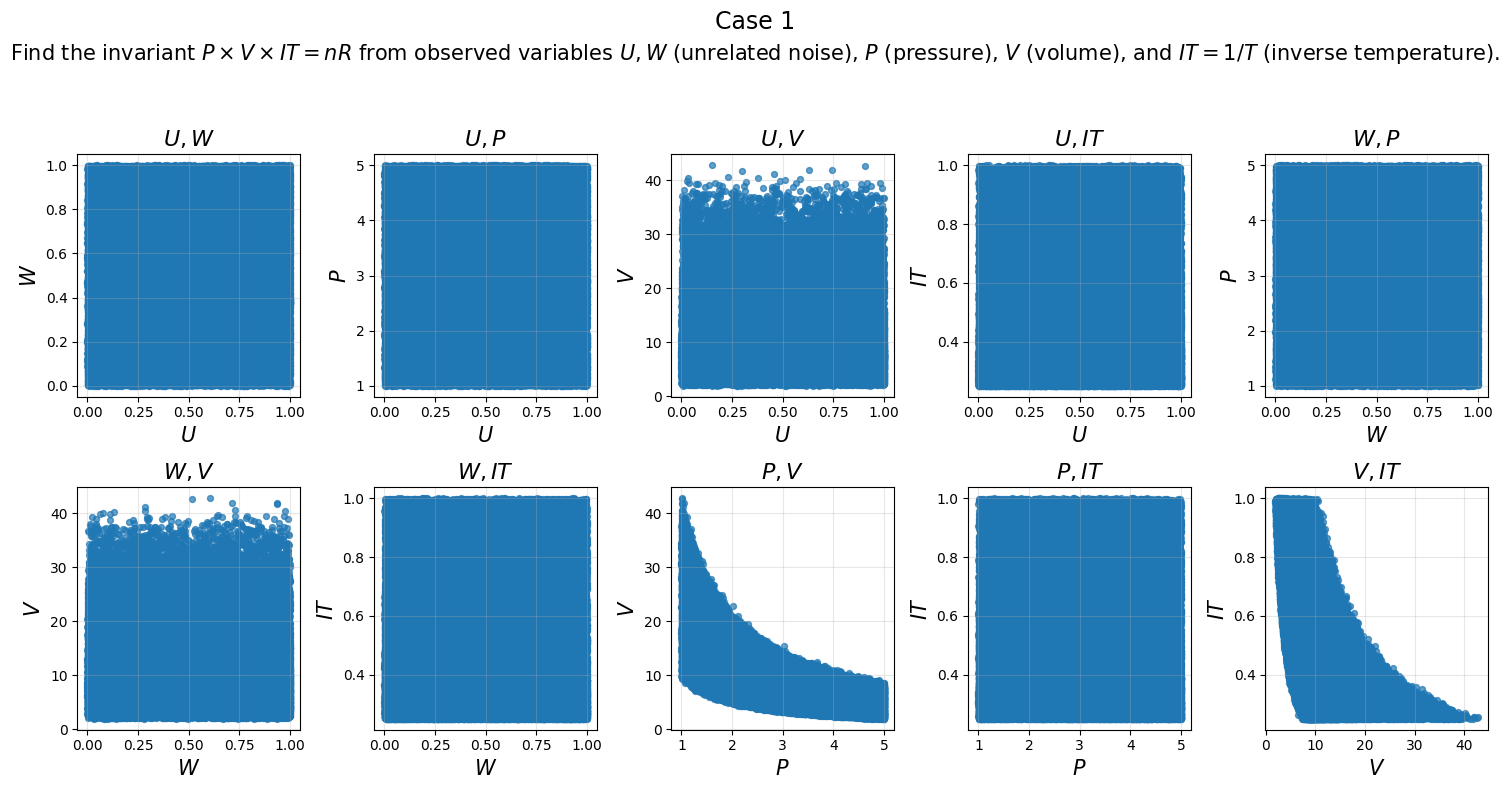

In [ ]:
# ============================================================
# Data visualization
# ============================================================

names = [r"$U$", r"$W$", r"$P$", r"$V$", r"$IT$"]

pairs = [
    (0, 1),
    (0, 2),
    (0, 3),
    (0, 4),
    (1, 2),
    (1, 3),
    (1, 4),
    (2, 3),
    (2, 4),
    (3, 4)
    ]

labels = [
    r"$U,W$",
    r"$U,P$",
    r"$U,V$",
    r"$U,IT$",
    r"$W,P$",
    r"$W,V$",
    r"$W,IT$",
    r"$P,V$",
    r"$P,IT$",
    r"$V,IT$"
]


# ============================================================
# ============================================================


fig, axes = plt.subplots(2, 5, figsize=(15, 8))

fig.suptitle(
    "Case 1",
    fontsize=fontsize + 2,
    y=0.98,
)

fig.text(
    0.5,
    0.925,
    r"Find the invariant $P \times V \times IT = nR$ from observed variables "
    r"$U, W$ (unrelated noise), $P$ (pressure), $V$ (volume), and $IT=1/T$ (inverse temperature).",
    ha="center",
    va="center",
    fontsize=fontsize,
)


for ax, (i, j), label in zip(axes.ravel(), pairs, labels):
    ax.scatter(
        X[:, i],
        X[:, j],
        s=18,
        alpha=0.7,
    )

    ax.set_xlabel(names[i], fontsize=fontsize)
    ax.set_ylabel(names[j], fontsize=fontsize)
    ax.set_title(label, fontsize=fontsize + 1)

    ax.grid(alpha=0.3)

fig.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

In [ ]:
# ============================================================
# Step 2. Define the canonical statistics function h
# ============================================================
def h_ideal_gas_inverse_temperature_dependence(v):
    U, W, P, V, IT = v

    return np.array([
        # degree-2 terms
        U * W,
        U * P,
        U * V,
        U * IT,
        W * P,
        W * V,
        W * IT,
        P * V,
        P * IT,
        V * IT,

        # degree-3 terms
        U * W * P,
        U * W * IT,
        U * P * V,
        U * P * IT,
        U * V * IT,
        W * P * V,
        W * P * IT,
        W * V * IT,
        P * V * IT,

        # degree-4 terms
        U * W * P * V,
        U * W * P * IT,
        U * W * V * IT,
        U * P * V * IT,
        W * P * V * IT,
    ], dtype=float)

In [ ]:
# ============================================================
# Step 3. Run PLE inference
# ============================================================

PLE_PVIT = mindemo.mindemo_Besag_SGD(
      X=X,
      h=h_ideal_gas_inverse_temperature_dependence,
      optimizer="adam",
      max_iter=20000,
      use_rpj=False
  )[0]

In [ ]:
# ============================================================
# Step 4. Run bootstrap inference
# ============================================================

PLE_boot_PVIT, PLE_bootm_PVIT, PLE_bootcov_PVIT = mindemo.mindemo_Besag_bootstrap_SGD_Multicore(
      X=X,
      h=h_ideal_gas_inverse_temperature_dependence,
      use_rpj=True,
      init=PLE_PVIT,
      avg_start=5000,
      max_iter=10000,
      B=200,
)

## Result Interpretation for Case 1

---

### 日本語

このセクションでは、推定された PLE 係数と Bootstrap 推論の結果を確認します。

- 係数の絶対値が大きい項は、候補となる従属構造です。
- 信頼区間が 0 をまたがない項は、より安定した検出結果として扱えます。
- `result_df_PVIT` では、係数、標準誤差、p 値、BH 補正後の q 値を確認できます。
- 想定どおりであれば、`P*V*IT` に対応する項が上位に現れます。

### English

This section examines the estimated PLE coefficients and the results of Bootstrap inference.

- Terms with larger absolute coefficient values are candidate dependency structures.
- Terms whose confidence intervals do not cross 0 can be treated as more stable detections.
- In `result_df_PVIT`, you can inspect coefficients, standard errors, p-values, and BH-adjusted q-values.
- If the experiment works as expected, the term corresponding to `P*V*IT` should appear among the top results.


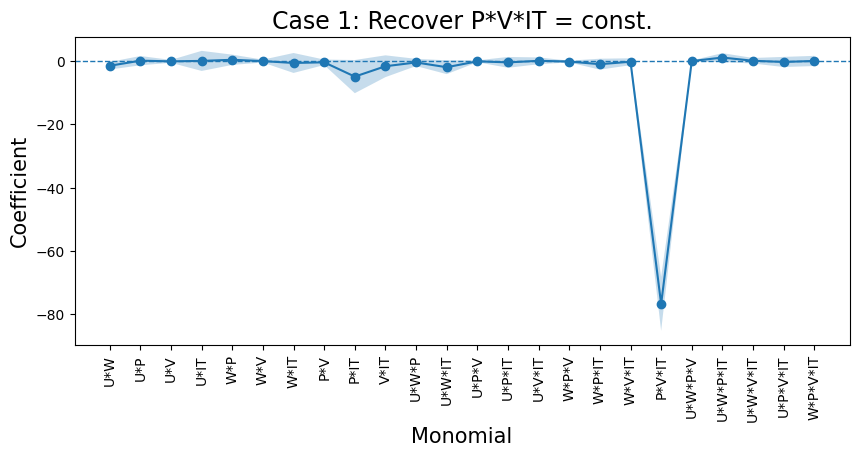

In [ ]:
# ============================================================
# Result visualization: estimated coefficients
# ============================================================

labels = [
    # degree-2 terms
    "U*W",
    "U*P",
    "U*V",
    "U*IT",
    "W*P",
    "W*V",
    "W*IT",
    "P*V",
    "P*IT",
    "V*IT",

    # degree-3 terms
    "U*W*P",
    "U*W*IT",
    "U*P*V",
    "U*P*IT",
    "U*V*IT",
    "W*P*V",
    "W*P*IT",
    "W*V*IT",
    "P*V*IT",

    # degree-4 terms
    "U*W*P*V",
    "U*W*P*IT",
    "U*W*V*IT",
    "U*P*V*IT",
    "W*P*V*IT",
]

ple_coef = np.asarray(PLE_bootm_PVIT, dtype=float)
ple_sigma = np.sqrt(np.diag(PLE_bootcov_PVIT))

# ============================================================
# ============================================================

fig, ax = plt.subplots(1, 1, figsize=(10, 4))

ax.set_title("Case 1: Recover P*V*IT = const.", fontsize=fontsize + 2)

ax.plot(labels, ple_coef, marker="o", label="Mindemo PLE")
ax.fill_between(
    labels,
    ple_coef - 1.96 * ple_sigma,
    ple_coef + 1.96 * ple_sigma,
    alpha=0.25)
ax.axhline(0.0, linewidth=1, linestyle="--")
ax.set_ylabel("Coefficient", fontsize=fontsize)
ax.set_xlabel("Monomial", fontsize=fontsize)
ax.tick_params(axis="x", labelrotation=90)
plt.show()

In [ ]:
# ============================================================
# Inference summary: bootstrap inference results
# ============================================================

result_df_PVIT = mindemo.mindemo_bootstrapinference_summary(
    coef=PLE_bootm_PVIT,
    boot=PLE_boot_PVIT,
    labels=labels,
    fdr_alpha=0.1
)
result_df_PVIT

,term,coef,ci_low_2.5%,ci_high_97.5%,p_value,q_value_BH,-log10(q),FDR_q<0.1,CI_excludes_0
0,U*W,-1.427814,-2.614621,-0.363827,0.02,0.240,0.619789,False,True
1,U*P,0.183380,-1.268569,1.540914,0.83,0.930,0.031517,False,False
2,U*V,-0.036187,-0.463599,0.400947,0.86,0.930,0.031517,False,False
3,U*IT,0.108095,-3.360319,3.091694,0.90,0.930,0.031517,False,False
4,W*P,0.462855,-1.064154,2.213765,0.61,0.930,0.031517,False,False
5,W*V,0.042346,-0.356108,0.459291,0.93,0.930,0.031517,False,False
6,W*IT,-0.547991,-3.903570,2.261567,0.78,0.930,0.031517,False,False
7,P*V,-0.334568,-1.171444,0.574890,0.46,0.930,0.031517,False,False
8,P*IT,-4.862511,-10.628593,0.441391,0.08,0.480,0.318759,False,False
9,V*IT,-1.579135,-5.079937,1.747130,0.43,0.930,0.031517,False,False


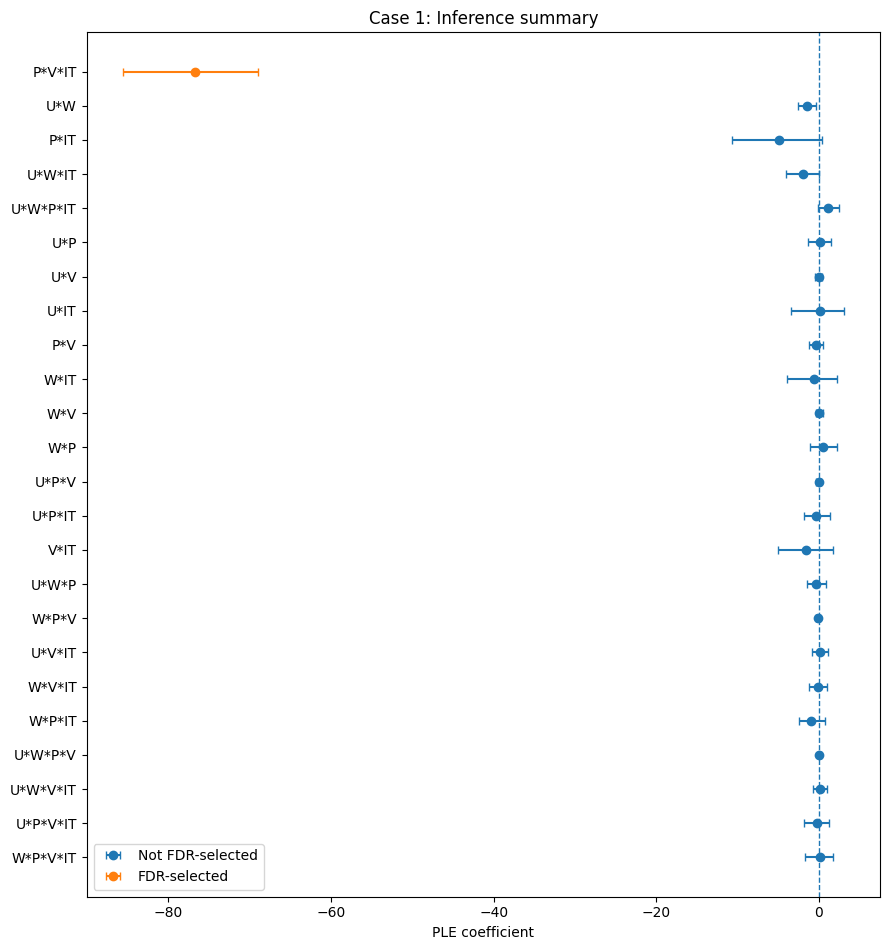

In [ ]:
# ============================================================
# Result visualization: forest plot of estimated PLE coefficients sorted by q-value
# ============================================================

fig, ax = mindemo.mindemo_plot_bootstrap_forest(
    result_df_PVIT,
    top_n=30,
    sort_by="-log10(q)",
    ascending=False,
    fdr_alpha=0.1,
    title="Case 1: Inference summary",
)

# Case 2: Penguins


## Case 2 Instructions: Penguins Data / Case 2 の説明

### 日本語

このケースでは、`palmerpenguins` の Adelie ペンギンデータを使い、形態測定値と性別の間にある2次・3次相互作用を調べます。

#### 前処理の内容

- `species == "Adelie"` のデータだけを使います。
- `island` と `year` は除外します。
- 欠損値を含む行は削除します。
- 連続変数は標準化します。
- `sex` は male = 1, female = 0 に変換します。

#### 解釈上の注意

- 得られた結果は各変数の従属関係であり因果関係を意味しません。
- Penguin データはサンプルサイズが Case 1 より小さいため、Bootstrap 結果は設定に敏感になる場合があります。

### English

In this case, we use Adelie penguin data from `palmerpenguins` to examine second- and third-order interactions among morphological measurements and sex.

#### Preprocessing steps

- Only observations with `species == "Adelie"` are used.
- `island` and `year` are excluded.
- Rows with missing values are removed.
- Continuous variables are standardized.
- `sex` is converted to male = 1 and female = 0.

#### Interpretation notes

- The results indicate statistical dependencies among variables, not causal relationships.
- The Penguin dataset has a smaller sample size than Case 1, so Bootstrap results may be sensitive to parameter settings.


In [ ]:
from palmerpenguins import load_penguins
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

# ============================================================
# Step 1: Prepare the penguins data
# ============================================================

penguins = load_penguins()
df = penguins.copy()

processed_df = (
    df[df["species"] == "Adelie"]
    .drop(["species", "island", "year"], axis=1)
    .dropna(how="any")
    .copy()
)

scaling_columns = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
]

sc = StandardScaler().fit(processed_df[scaling_columns])

scaled_df = pd.DataFrame(
    sc.transform(processed_df[scaling_columns]),
    columns=scaling_columns,
    index=processed_df.index,
)

processed_df.update(scaled_df)

processed_df["sex"] = processed_df["sex"].map({"male": 1, "female": 0})

X_penguins = processed_df.values.tolist()

base_labels = processed_df.columns.tolist()
base_labels

['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']

In [ ]:
# ============================================================
# Step 2: Define the canonical statistics function h for pairwise and three-way interactions
# ============================================================

def h_penguins_all_3factor(x):
    h_list = []

    # Two-factor interactions
    for i in range(5):
        for j in range(i + 1, 5):
            h_list.append(x[i] * x[j])

    # Three-factor interactions
    for i in range(5):
        for j in range(i + 1, 5):
            for k in range(j + 1, 5):
                h_list.append(x[i] * x[j] * x[k])

    return np.array(h_list)


def make_penguins_all_3factor_labels(base_labels):
    labels = []

    # Two-factor labels
    for i in range(5):
        for j in range(i + 1, 5):
            labels.append(f"{base_labels[i]} × {base_labels[j]}")

    # Three-factor labels
    for i in range(5):
        for j in range(i + 1, 5):
            for k in range(j + 1, 5):
                labels.append(
                    f"{base_labels[i]} × {base_labels[j]} × {base_labels[k]}"
                )

    return labels


penguins_labels = make_penguins_all_3factor_labels(base_labels)

In [ ]:
# ============================================================
# Step 3: Run PLE inference
# ============================================================

PLE_penguins = mindemo.mindemo_Besag_SGD(
    X=X_penguins,
    h=h_penguins_all_3factor,
    optimizer="adam",
    max_iter=20000,
    use_rpj=False,
)[0]

In [ ]:
# ============================================================
# Step 4: Run bootstrap inference
# ============================================================

PLE_boot_penguins, PLE_bootm_penguins, PLE_bootcov_penguins = (
    mindemo.mindemo_Besag_bootstrap_SGD_Multicore(
        X=X_penguins,
        h=h_penguins_all_3factor,
        use_rpj=True,
        init=PLE_penguins,
        avg_start=5000,
        max_iter=10000,
        B=200,
        n_jobs=-1,
        seed=123,
        progress=True,
    )
)

[20/200] finished
[40/200] finished
[60/200] finished
[80/200] finished
[100/200] finished
[120/200] finished
[140/200] finished
[160/200] finished
[180/200] finished
[200/200] finished


## Result Interpretation for Case 2

### 日本語

このセクションでは、Penguin データにおける2次・3次相互作用の推定結果を確認します。

- `penguins_labels` は各相互作用項の名前です。
- 係数プロットでは、どの相互作用が大きく推定されたかを確認します。
- `result_df_penguins` では、q 値や効果量を見て、上位の従属候補を確認します。
- Hypergraph 可視化では、3変数間の強い従属候補をネットワークとして表示します。
- 変数名の略称は、`Bl` = Bill length, `Bd` = Bill depth, `Fl` = Flipper length, `Bm` = Body mass, `Se` = Sex です。

### English

This section reviews the estimated second- and third-order interactions in the Penguin data.

- `penguins_labels` contains the names of the interaction terms.
- The coefficient plot shows which interactions were estimated to be large.
- In `result_df_penguins`, inspect q-values and effect sizes to identify the top dependency candidates.
- The hypergraph visualization displays strong candidate dependencies among three variables as a network-like structure.
- Variable abbreviations are `Bl` = Bill length, `Bd` = Bill depth, `Fl` = Flipper length, `Bm` = Body mass, and `Se` = Sex.


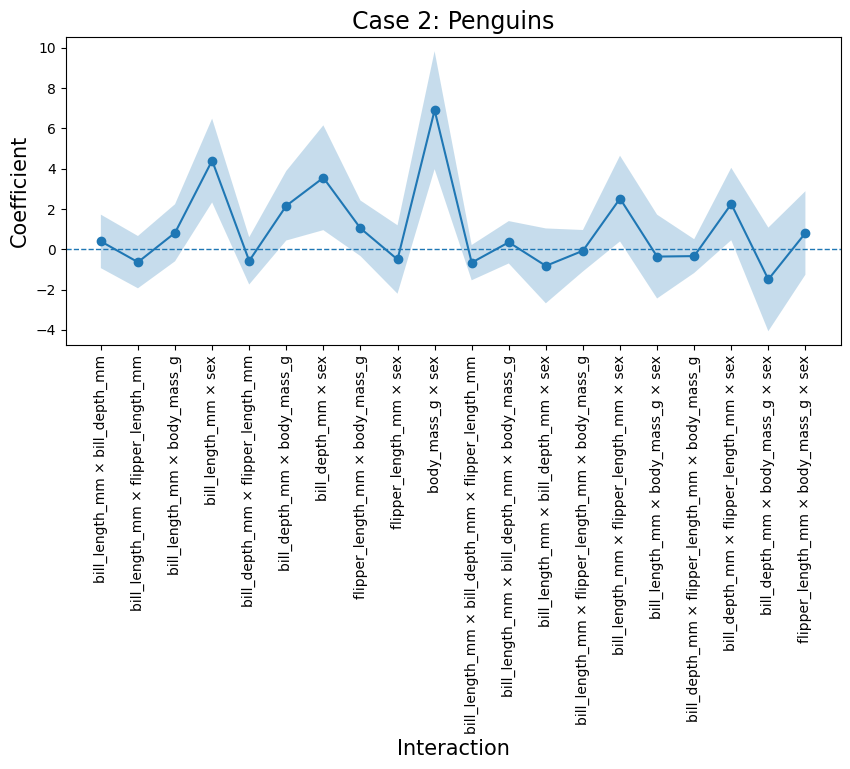

In [ ]:
# ============================================================
# Result visualization: estimated coefficients
# ============================================================

ple_coef = np.asarray(PLE_bootm_penguins, dtype=float)
ple_sigma = np.sqrt(np.diag(PLE_bootcov_penguins))


# ============================================================
# ============================================================

fig, ax = plt.subplots(1, 1, figsize=(10, 4))

ax.set_title("Case 2: Penguins", fontsize=fontsize + 2)

ax.plot(penguins_labels, ple_coef, marker="o", label="Mindemo PLE")
ax.fill_between(
    penguins_labels,
    ple_coef - 1.96 * ple_sigma,
    ple_coef + 1.96 * ple_sigma,
    alpha=0.25)
ax.axhline(0.0, linewidth=1, linestyle="--")
ax.set_ylabel("Coefficient", fontsize=fontsize)
ax.set_xlabel("Interaction", fontsize=fontsize)
ax.tick_params(axis="x", labelrotation=90)
plt.show()

In [ ]:
# ============================================================
# Inference summary: bootstrap inference results
# ============================================================
result_df_penguins = mindemo.mindemo_bootstrapinference_summary(
    coef=PLE_bootm_penguins,
    boot=PLE_boot_penguins,
    labels=penguins_labels,
    fdr_alpha=0.2,
)
result_df_penguins

,term,coef,ci_low_2.5%,ci_high_97.5%,p_value,q_value_BH,-log10(q),FDR_q<0.2,CI_excludes_0
0,bill_length_mm × bill_depth_mm,0.388280,-0.913447,1.595465,0.55,0.647059,0.189056,False,False
1,bill_length_mm × flipper_length_mm,-0.642324,-1.873197,0.655164,0.34,0.560000,0.251812,False,False
2,bill_length_mm × body_mass_g,0.815712,-0.277354,2.344334,0.23,0.511111,0.291485,False,False
3,bill_length_mm × sex,4.401300,2.681333,6.496952,0.00,0.000000,2.303196,True,True
4,bill_depth_mm × flipper_length_mm,-0.578358,-1.907798,0.621766,0.28,0.527273,0.277965,False,False
5,bill_depth_mm × body_mass_g,2.157116,0.444944,3.693977,0.00,0.000000,2.303196,True,True
6,bill_depth_mm × sex,3.547601,1.450074,6.511453,0.00,0.000000,2.303196,True,True
7,flipper_length_mm × body_mass_g,1.039402,-0.346943,2.317968,0.16,0.400000,0.397940,False,False
8,flipper_length_mm × sex,-0.510186,-2.294068,1.126395,0.61,0.677778,0.168913,False,False
9,body_mass_g × sex,6.899086,4.448825,9.743911,0.00,0.000000,2.303196,True,True


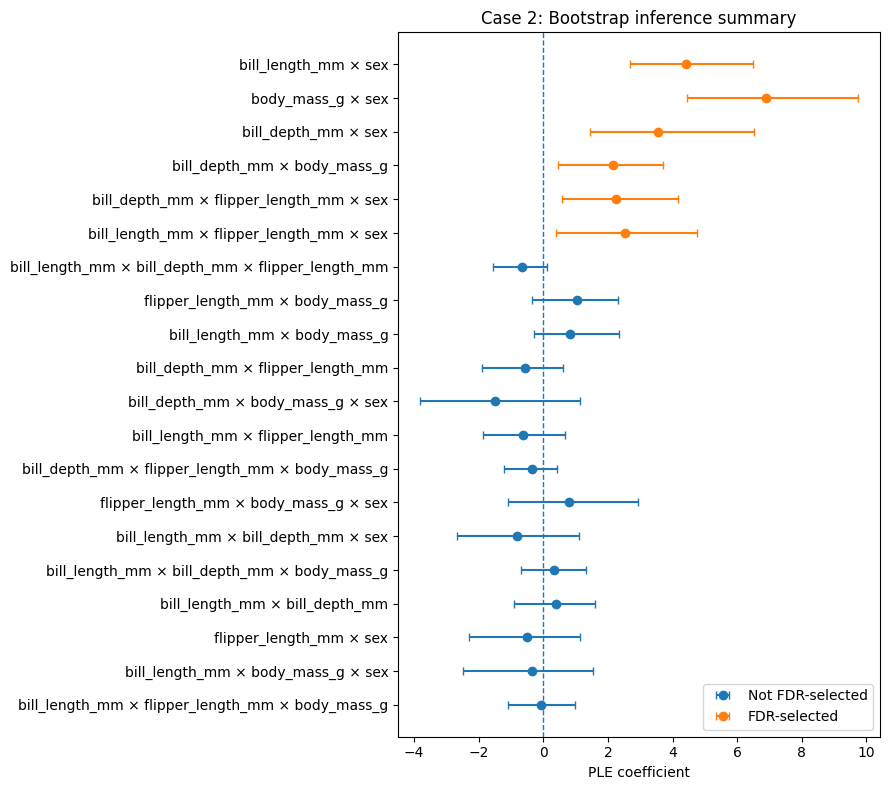

In [ ]:
# ============================================================
# Result visualization: forest plot of estimated PLE coefficients sorted by q-value
# ============================================================
fig, ax = mindemo.mindemo_plot_bootstrap_forest(
    result_df_penguins,
    top_n=30,
    sort_by="-log10(q)",
    ascending=False,
    fdr_alpha=0.1,
    title="Case 2: Bootstrap inference summary",
)

In [ ]:
# ============================================================
# Result visualization: plot the dependency hypergraph
# ============================================================


def plot_qvalue_hypergraph_3factor(
    result_df,
    *,
    variables=None,
    d=5,
    top_k=3,
    fdr_alpha=0.05,
    q_col="q_value_BH",
    score_col="-log10(q)",
    coef_col="coef",
    title="Estimated dependence hypergraph based on BH q-values",
    seed=123,
    figsize=(8, 4),
    fontsize=14,
):
    """
    Visualize the top three-factor interactions using BH q-values.

    Parameters
    ----------
    result_df : pandas.DataFrame
        Output of mindemo_bootstrapinference_summary.
        Assumes rows are ordered as:
        first C(d, 2) pairwise interactions,
        then C(d, 3) three-way interactions.

    variables : list[str] or None
        Node labels. If None, use V1, ..., Vd.

    d : int
        Number of base variables.

    top_k : int
        Number of three-factor interactions to highlight.

    fdr_alpha : float
        FDR threshold.

    q_col : str
        q-value column name.

    score_col : str
        Score column name, usually "-log10(q)".

    coef_col : str
        Coefficient column name.

    title : str
        Plot title.

    seed : int
        Seed for networkx layout.

    Returns
    -------
    fig, ax
    """

    if variables is None:
        variables = [f"V{i+1}" for i in range(d)]

    if len(variables) != d:
        raise ValueError("variables must have length d.")

    df = result_df.copy().reset_index(drop=True)

    base_3factor = int(d * (d - 1) / 2)
    expected_p = base_3factor + int(d * (d - 1) * (d - 2) / 6)

    if len(df) < expected_p:
        raise ValueError(
            f"result_df has {len(df)} rows, but expected at least {expected_p} "
            f"for all 2-factor and 3-factor interactions."
        )

    # ------------------------------------------------------------
    # Build pairwise base graph
    # ------------------------------------------------------------
    graph = nx.Graph()
    graph.add_nodes_from(variables)

    pair_edges = []
    pair_idx = []

    idx = 0
    for i in range(d):
        for j in range(i + 1, d):
            edge = (variables[i], variables[j])
            pair_edges.append(edge)
            pair_idx.append(idx)
            graph.add_edge(*edge)
            idx += 1

    # ------------------------------------------------------------
    # Recover the three-factor index map in the same order as h
    # ------------------------------------------------------------
    triple_records = []

    row_idx = base_3factor
    for i in range(d):
        for j in range(i + 1, d):
            for k in range(j + 1, d):
                triple_records.append({
                    "row_idx": row_idx,
                    "triple": (i, j, k),
                    "nodes": (variables[i], variables[j], variables[k]),
                    "term": df.loc[row_idx, "term"],
                    "coef": float(df.loc[row_idx, coef_col]),
                    "q_value": float(df.loc[row_idx, q_col]),
                    "score": float(df.loc[row_idx, score_col]),
                    "selected": bool(df.loc[row_idx, q_col] < fdr_alpha),
                })
                row_idx += 1

    triple_df = (
        pd.DataFrame(triple_records)
        .sort_values(["q_value", "score"], ascending=[True, False])
        .head(top_k)
        .reset_index(drop=True)
    )

    # ------------------------------------------------------------
    # Draw graph
    # ------------------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    pos = nx.spring_layout(graph, seed=seed)

    # Node colors: treat the last variable as sex-like when d=5
    node_colors = ["tab:blue"] * d
    if d == 5:
        node_colors[-1] = "tab:red"

    nx.draw_networkx_nodes(
        graph,
        pos,
        node_size=650,
        alpha=0.8,
        node_color=node_colors,
        ax=ax,
    )

    # Pairwise background edges
    pair_scores = np.asarray(df.loc[pair_idx, score_col], dtype=float)
    if np.nanmax(pair_scores) > 0:
        pair_alpha = 0.15 + 0.45 * pair_scores / np.nanmax(pair_scores)
    else:
        pair_alpha = np.full(len(pair_edges), 0.25)

    for e, a in zip(pair_edges, pair_alpha):
        nx.draw_networkx_edges(
            graph,
            pos,
            edgelist=[e],
            width=1.5,
            alpha=float(a),
            ax=ax,
        )

    nx.draw_networkx_labels(
        graph,
        pos,
        font_size=16,
        font_color="black",
        ax=ax,
    )

    # ------------------------------------------------------------
    # Highlight top three-factor hyperedges as triangles
    # ------------------------------------------------------------
    colors = ["green", "orange", "pink", "purple", "brown", "gray"]

    max_score = max(float(triple_df["score"].max()), 1e-12)

    for r, row in triple_df.iterrows():
        a, b, c = row["nodes"]

        triangle_edges = [
            (a, b),
            (b, c),
            (c, a),
        ]

        width = 3.0 + 7.0 * float(row["score"]) / max_score
        alpha = 0.35 + 0.45 * float(row["score"]) / max_score

        style = "solid" if row["selected"] else "dashed"

        nx.draw_networkx_edges(
            graph,
            pos,
            edgelist=triangle_edges,
            width=width,
            edge_color=colors[r % len(colors)],
            alpha=alpha,
            style=style,
            ax=ax,
        )

    # ------------------------------------------------------------
    # Annotate selected top interactions
    # ------------------------------------------------------------
    label_lines = []
    for r, row in triple_df.iterrows():
        sig_mark = "*" if row["selected"] else ""
        label_lines.append(
            f"{r+1}. {row['term']} | q={row['q_value']:.3g}, "
            f"coef={row['coef']:.3g}{sig_mark}"
        )

    ax.text(
        1.02,
        0.5,
        "\n".join(label_lines),
        transform=ax.transAxes,
        va="center",
        ha="left",
        fontsize=10,
    )

    ax.set_title(title, fontsize=fontsize)
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

    fig.tight_layout()
    return fig, ax, triple_df

,row_idx,triple,nodes,term,coef,q_value,score,selected
0,17,"(1, 2, 4)","(Bd, Fl, Se)",bill_depth_mm × flipper_length_mm × sex,2.243548,0.000000,2.303196,True
1,14,"(0, 2, 4)","(Bl, Fl, Se)",bill_length_mm × flipper_length_mm × sex,2.513204,0.033333,1.477121,True
2,10,"(0, 1, 2)","(Bl, Bd, Fl)",bill_length_mm × bill_depth_mm × flipper_lengt...,-0.666088,0.257143,0.589826,False


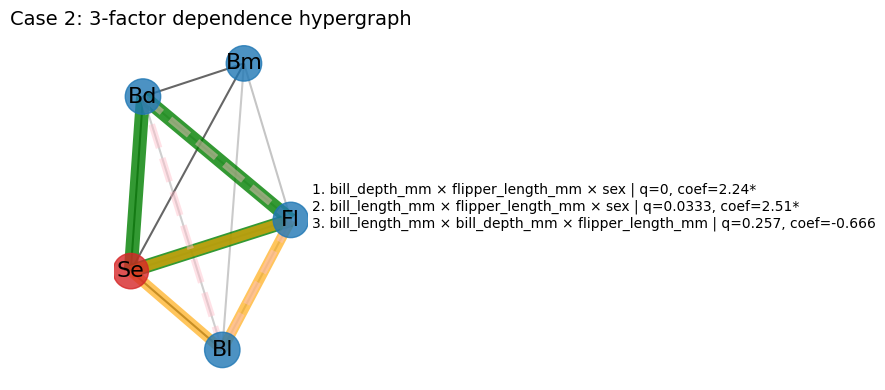

In [ ]:
# ============================================================
# Result visualization: plot the dependence hypergraph
# ============================================================

variables = ["Bl", "Bd", "Fl", "Bm", "Se"]

fig, ax, top3_q_hyperedges = plot_qvalue_hypergraph_3factor(
    result_df_penguins,
    variables=variables,
    d=5,
    top_k=3,
    fdr_alpha=0.1,
    title="Case 2: 3-factor dependence hypergraph",
)

top3_q_hyperedges